#### importation of our modules such as numpy, pandas, matplotlib, seaborn|

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### importation of our csv dataset using the pandas read_csv function and storing it in a variable

In [2]:
df = pd.read_csv(r"C:\Users\Child's Play\Documents\Datasets\coffee.csv")

#### changing our date column from strings to datetime

In [3]:
df['date'] = pd.to_datetime(df['date'])

In [4]:
df

,date,cash_type,money,coffee_name
0,2024-03-01,card,38.70,Latte
1,2024-03-01,card,38.70,Hot Chocolate
2,2024-03-01,card,38.70,Hot Chocolate
3,2024-03-01,card,28.90,Americano
4,2024-03-01,card,38.70,Latte
...,...,...,...,...
3631,2025-03-23,card,35.76,Cappuccino
3632,2025-03-23,card,35.76,Cocoa
3633,2025-03-23,card,35.76,Cocoa
3634,2025-03-23,card,25.96,Americano


#### performing descriptive analysis on the numerical columns in our dataset

In [5]:
df.describe()

,date,money
count,3636,3636.000000
mean,2024-09-30 11:56:02.376237568,31.746859
min,2024-03-01 00:00:00,18.120000
25%,2024-07-03 00:00:00,27.920000
50%,2024-10-06 12:00:00,32.820000
75%,2025-01-08 00:00:00,35.760000
max,2025-03-23 00:00:00,40.000000
std,NaN,4.919926


#### performing descriptive statistics on string columns 

In [6]:
df.describe(include='object')

,cash_type,coffee_name
count,3636,3636
unique,2,8
top,card,Americano with Milk
freq,3547,824


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         3636 non-null   datetime64[ns]
 1   cash_type    3636 non-null   object        
 2   money        3636 non-null   float64       
 3   coffee_name  3636 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 113.8+ KB


In [8]:
df.shape

(3636, 4)

In [9]:
# find the rows with no duplicates and storing it as our new dataframe and since it will make the index a lil bit
# not in sequence, we use the "reset_index" and we use the drop keyword and set it to true because it created a new col

df = df.loc[~df.duplicated(subset=['date', 'cash_type', 'money', 'coffee_name'])] \
.reset_index(drop=True)

In [10]:
# we rechecked the shape of our dataset after removing the duplicates to see that we have 1762 rows and 4 columns
df.shape

(1762, 4)

In [11]:
df

,date,cash_type,money,coffee_name
0,2024-03-01,card,38.70,Latte
1,2024-03-01,card,38.70,Hot Chocolate
2,2024-03-01,card,28.90,Americano
3,2024-03-01,card,33.80,Americano with Milk
4,2024-03-01,card,38.70,Cocoa
...,...,...,...,...
1757,2025-03-22,card,35.76,Latte
1758,2025-03-23,card,35.76,Latte
1759,2025-03-23,card,35.76,Cappuccino
1760,2025-03-23,card,35.76,Cocoa


In [12]:
df.dtypes

date           datetime64[ns]
cash_type              object
money                 float64
coffee_name            object
dtype: object

In [13]:
df['coffee_name'].value_counts()

coffee_name
Latte                  327
Americano with Milk    325
Cappuccino             268
Americano              255
Cortado                176
Hot Chocolate          162
Cocoa                  142
Espresso               107
Name: count, dtype: int64

# EXPLORATORY DATA ANALYSIS #

### UNIVARIATE ANALYSIS ###
* Categorical(Barchart, piechart, countplot)

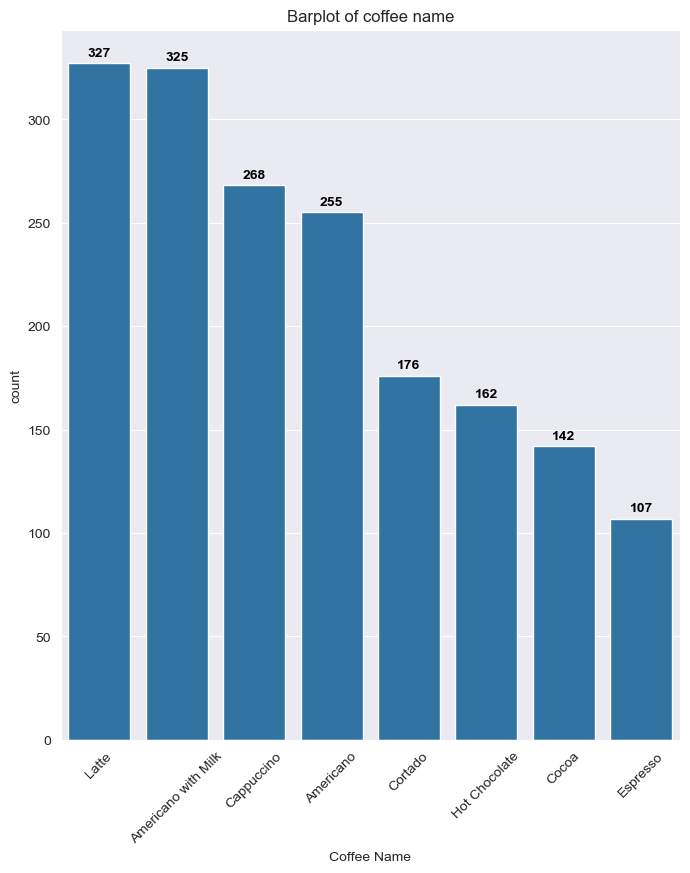

In [14]:
plt.figure(figsize=(7,8))
sns.set_style(style='darkgrid')
ax = sns.barplot(data=df['coffee_name'].value_counts())
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,           
        fontsize=10,
        fontweight='bold',
        color='black')

plt.title('Barplot of coffee name')
plt.xlabel('Coffee Name')
plt.tight_layout()
plt.xticks(rotation=45)
plt.savefig('Coffee Barplot.png', dpi=150, bbox_inches='tight')
plt.show()

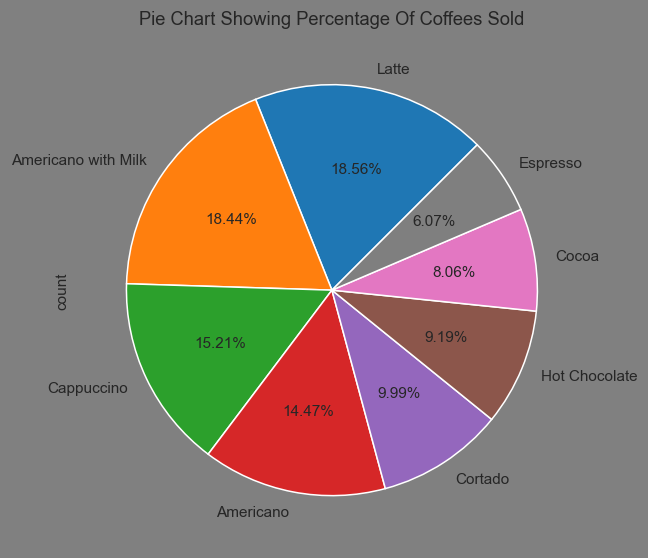

In [15]:
plt.figure(figsize=(6,7),dpi=110,facecolor='Gray')
df['coffee_name'].value_counts().plot.pie(autopct='%.2f%%', startangle=45)
plt.title('Pie Chart Showing Percentage Of Coffees Sold')
plt.tight_layout()
plt.savefig('Pie Chart of coffees.png', dpi=150, bbox_inches = 'tight')

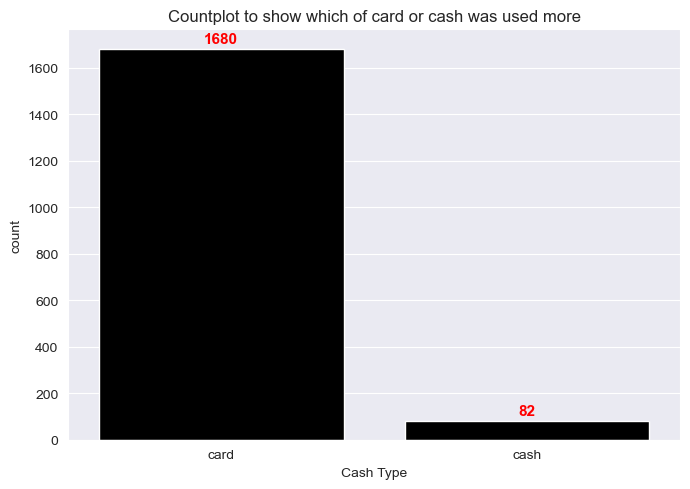

In [16]:
plt.figure(figsize=(7,5))
order_shii = df['cash_type'].value_counts().index
ax = sns.countplot(data=df, x='cash_type',color= 'black' ,order=order_shii)
for cont in ax.containers:
    ax.bar_label(
        cont,
        padding=2,
        fontweight='bold',
        fontsize=11,
        color = 'red'
    )
plt.title('Countplot to show which of card or cash was used more')
plt.xlabel('Cash Type')
plt.tight_layout()
plt.show()

### UNIVARIATE ANALYSIS ###
***Numerical Data(BoxPlot, Histogram, Kernel Density Plot)***

In [17]:
def numeric_box_visuals(data):
    for num_data in data.columns:
        if data[num_data].dtypes in ['int64', 'float64']:
            print('Descriptive Statistics of ', num_data,'\n' ,data[num_data].describe())
            sns.boxplot(data=data, x=num_data, color='#e5941e')
            plt.title(f'Box Plot of {num_data}')
            plt.xlabel(f'{num_data}')
            plt.show()
        else:
            pass

Descriptive Statistics of  money 
 count    1762.000000
mean       31.779387
std         5.291160
min        18.120000
25%        27.920000
50%        32.820000
75%        35.760000
max        40.000000
Name: money, dtype: float64


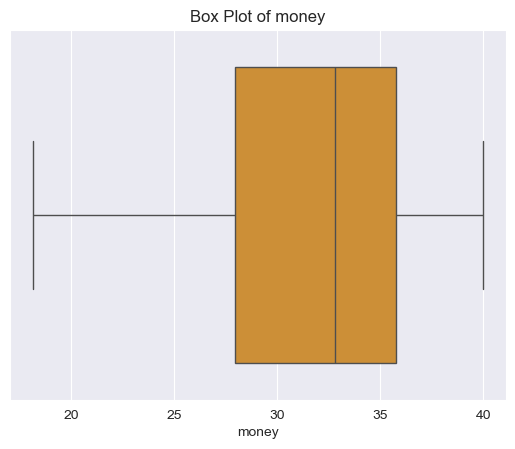

In [18]:
numeric_box_visuals(df)

In [19]:
def numeric_hist_visuals(data):
    for col in data.columns:
        if data[col].dtypes in ['int64', 'float64']:
            print(f'Visualisation of {col}')
            plt.figure(figsize=(5,5))
            sns.histplot(data=data, x=col, bins=20, color='#e5941e')
            plt.title(f'Histogram Showing Distribution of {col}')
            plt.xlabel(col)
            plt.ylabel('Frequency')
            plt.tight_layout()
            plt.show()
        else:
            pass

Visualisation of money


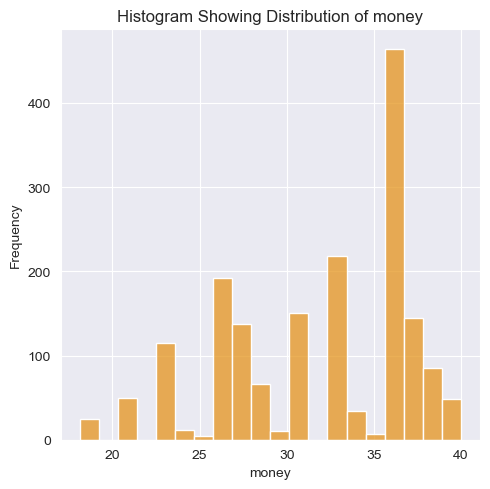

In [20]:
numeric_hist_visuals(df)

In [21]:
from scipy import stats

In [22]:
mode_of_df = stats.mode(df['money'])
mode_of_df

ModeResult(mode=np.float64(35.76), count=np.int64(464))

In [23]:
def numeric_kde_visuals(data):
    for col in data.columns:
        if data[col].dtypes in ['int64', 'float64']:
            print(f'Visualisation of {col}'.center(37, '*').capitalize)
            plt.figure(figsize=(5,5))
            sns.kdeplot(data=data, x=col, color='#e5941e')
            plt.title(f'Kernel Density Estimate Plot Showing Distribution of {col}')
            plt.xlabel(col)
            plt.ylabel('Frequency')
            plt.tight_layout()
            plt.show()
        else:
            pass

<built-in method capitalize of str object at 0x000000A624459CA0>


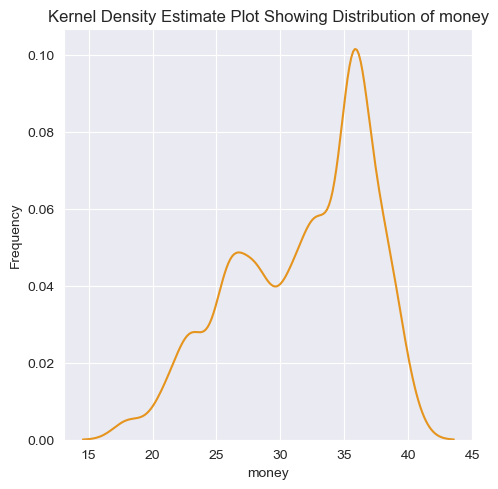

In [24]:
numeric_kde_visuals(df)

# BIVARIATE ANALYSIS #

***Categorical and Numerical (Coffee_Name and Money)(Boxplot)***

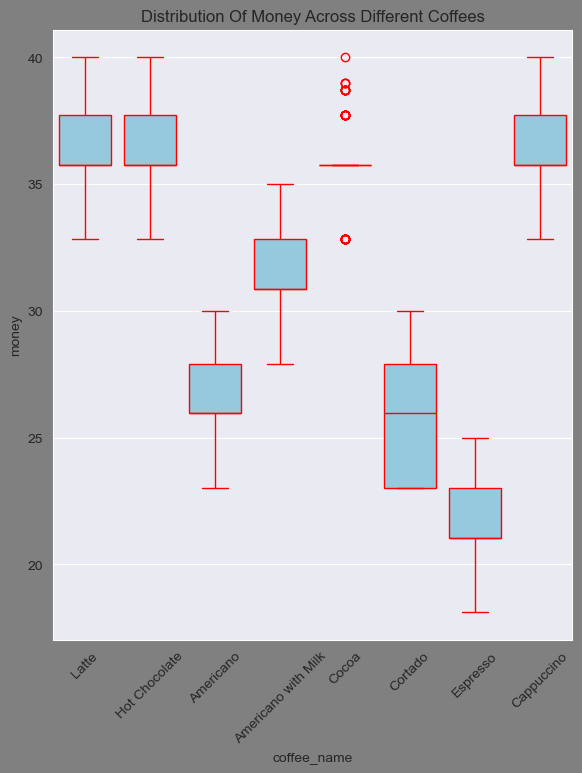

In [25]:
plt.figure(figsize=(6,7), facecolor='gray', dpi=100)
sns.boxplot(data=df, x='coffee_name', y='money',linecolor='red',color='skyblue')
plt.title('distribution of money across different coffees'.title())
plt.tight_layout()
plt.xticks(rotation=45)
#plt.savefig('money_vs_coffee_name.png', dpi=100, bbox_inches='tight')
plt.show()

In [26]:
df.groupby('coffee_name')['money'].describe()

,count,mean,std,min,25%,50%,75%,max
coffee_name,,,,,,,,
Americano,255.0,26.188078,1.996214,23.02,25.96,25.96,27.92,30.0
Americano with Milk,325.0,30.967938,1.989703,27.92,30.86,30.86,32.82,35.0
Cappuccino,268.0,36.084701,2.011999,32.82,35.76,35.76,37.72,40.0
Cocoa,142.0,35.789296,1.555840,32.82,35.76,35.76,35.76,40.0
Cortado,176.0,26.051818,2.147626,23.02,23.02,25.96,27.92,30.0
Espresso,107.0,21.134019,2.032716,18.12,21.06,21.06,23.02,25.0
Hot Chocolate,162.0,36.138765,1.652187,32.82,35.76,35.76,37.72,40.0
Latte,327.0,36.082630,2.094224,32.82,35.76,35.76,37.72,40.0


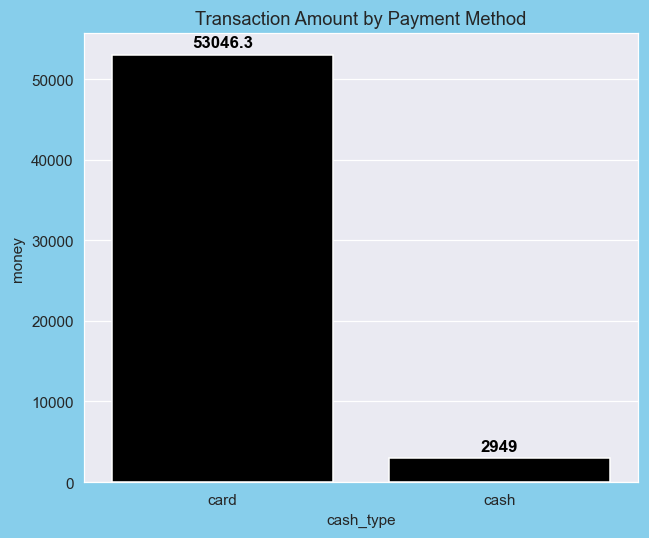

In [27]:
#df.groupby('cash_type')['money'].sum().plot.bar()
plt.figure(figsize=(6,5),dpi=110,facecolor='skyblue')
ax = sns.barplot(data=df.groupby('cash_type')['money'].sum(),color='black',errorbar=None)
for con in ax.containers:
    ax.bar_label(
        con,
        padding=3,
        fontsize=11,
        fontweight='bold',
        color='black'
    )
plt.title('Transaction Amount by Payment Method')
plt.tight_layout()
plt.show()

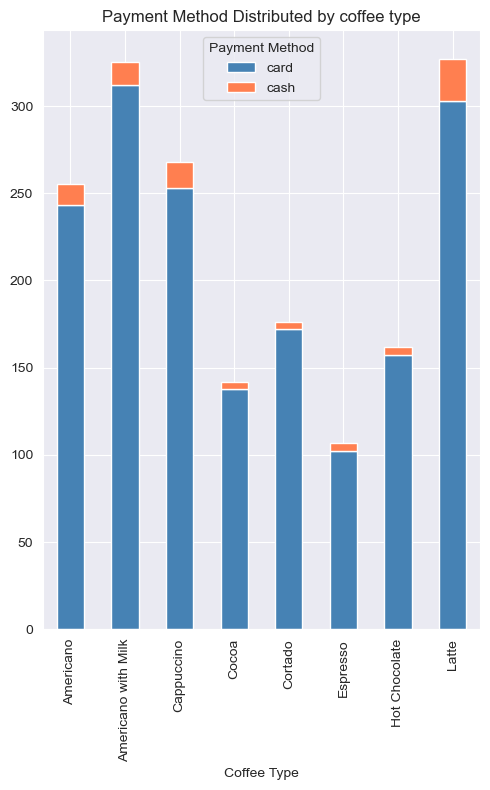

In [28]:
tab = pd.crosstab(df['coffee_name'], df['cash_type'])
tab.plot(kind='bar', stacked='True', color=['#4682B4','#FF7F50'], figsize=(5,8))
plt.title('Payment Method Distributed by coffee type')
plt.xlabel('Coffee Type')
plt.tight_layout()
plt.legend(title='Payment Method')
plt.gray()
plt.grid(visible=True)
plt.show()

In [29]:
tab

cash_type,card,cash
coffee_name,,
Americano,243,12
Americano with Milk,312,13
Cappuccino,253,15
Cocoa,138,4
Cortado,172,4
Espresso,102,5
Hot Chocolate,157,5
Latte,303,24


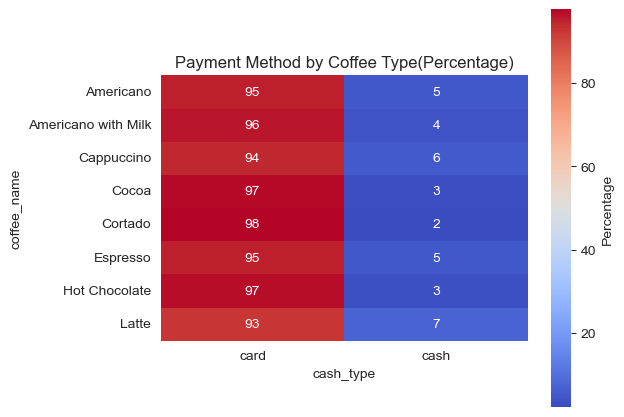

In [30]:
heat_tab = pd.crosstab(df['coffee_name'], df['cash_type'])
heat_tab = heat_tab.sort_index()
row_tab = heat_tab.div(heat_tab.sum(axis=1), axis=0) * 100
sns.heatmap(row_tab,annot=True,fmt='.0f',cmap='coolwarm',
            cbar_kws={'label':'Percentage','orientation':'vertical', 'shrink': 1.5})
plt.title('Payment Method by Coffee Type(Percentage)')
plt.tight_layout()
plt.show()

In [31]:
taB = round(pd.crosstab(df['coffee_name'], df['cash_type'], normalize='index') * 100,1)
taB

cash_type,card,cash
coffee_name,,
Americano,95.3,4.7
Americano with Milk,96.0,4.0
Cappuccino,94.4,5.6
Cocoa,97.2,2.8
Cortado,97.7,2.3
Espresso,95.3,4.7
Hot Chocolate,96.9,3.1
Latte,92.7,7.3


In [32]:
df['month'] = df['date'].dt.month_name()
df['year'] = df['date'].dt.year

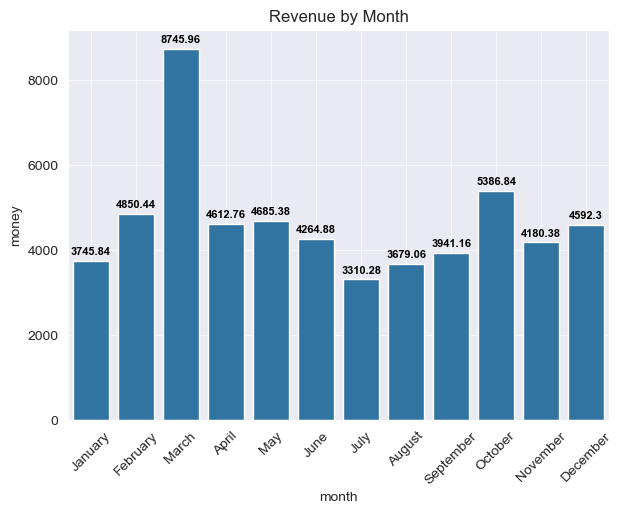

In [33]:
monthly_sales_by_sum = df.groupby('month')['money'].sum().reset_index()\
.sort_values('month',key=lambda x: pd.to_datetime(x, format='%B'))
monthly_sales_by_sum['month'] = monthly_sales_by_sum['month'].astype(str)
ax = sns.barplot(data=monthly_sales_by_sum, x='month', y='money')
for container_1 in ax.containers:
    ax.bar_label(
        container_1,
        padding=3,
        fontsize=8,
        fontweight='bold',
        color='black'
    )
plt.title('Revenue by Month')
plt.tight_layout()
plt.xticks(rotation=45)
plt.grid(visible=True,alpha=0.7)
plt.show()

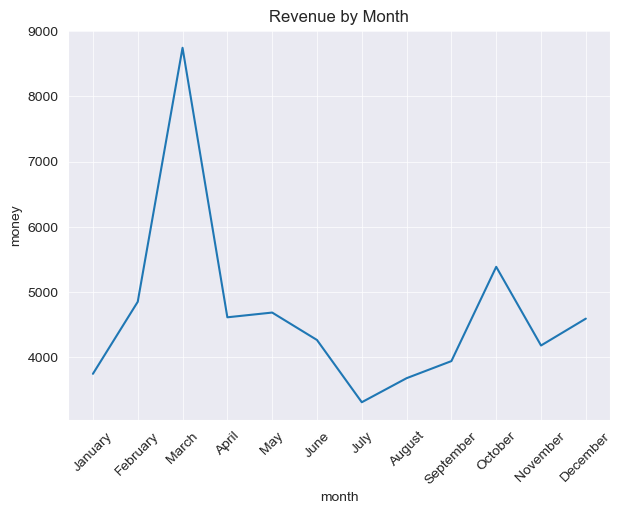

In [34]:
monthly_sales_by_sum = df.groupby('month')['money'].sum().reset_index()\
.sort_values('month', key=lambda x: pd.to_datetime(x, format='%B'))
monthly_sales_by_sum['month'] = monthly_sales_by_sum['month'].astype(str)
sns.lineplot(data=monthly_sales_by_sum, x='month', y='money',orient='x',markers=0)
plt.title('Revenue by Month')
plt.tight_layout()
plt.xticks(rotation=45)
plt.grid(visible=True,alpha=0.7)
plt.show()

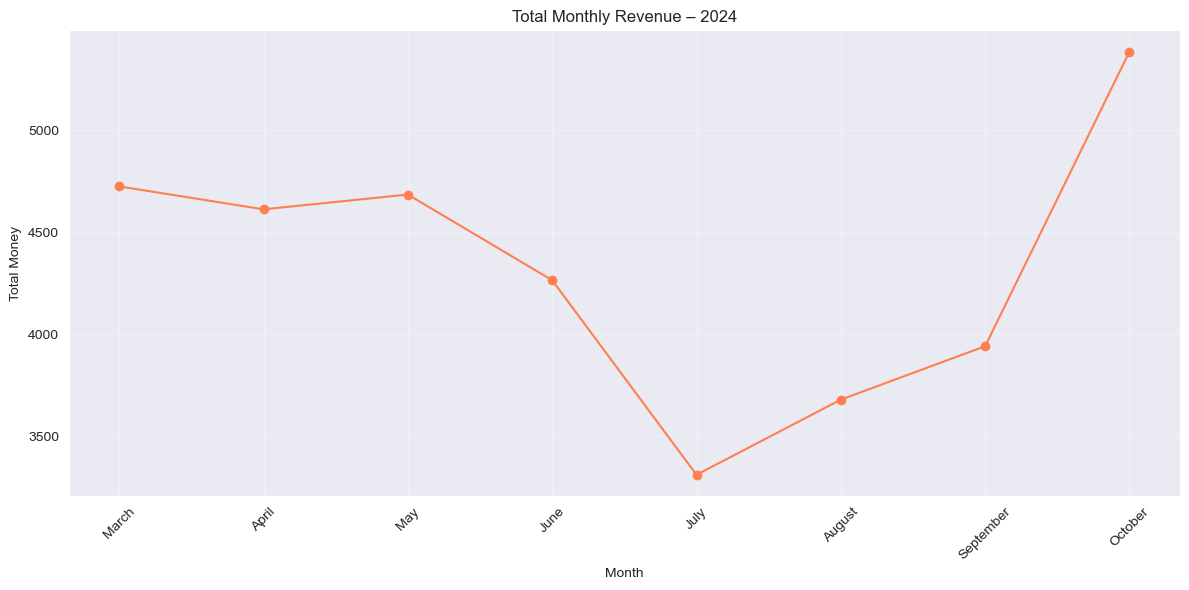

In [35]:
# Filter 2024
df_2024 = df[df['date'].dt.year == 2024]

monthly_total_2024 = df_2024.groupby(df_2024['date'].dt.month_name())['money'].sum()
monthly_total_2024 = monthly_total_2024.reindex(
    pd.date_range('2024-01-01', '2024-12-31', freq='ME').month_name() [:len(monthly_total_2024)] 
)

plt.figure(figsize=(12, 6))
monthly_total_2024.plot(kind='line', marker='o', color='coral')
plt.title('Total Monthly Revenue – 2024')
plt.ylabel('Total Money')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

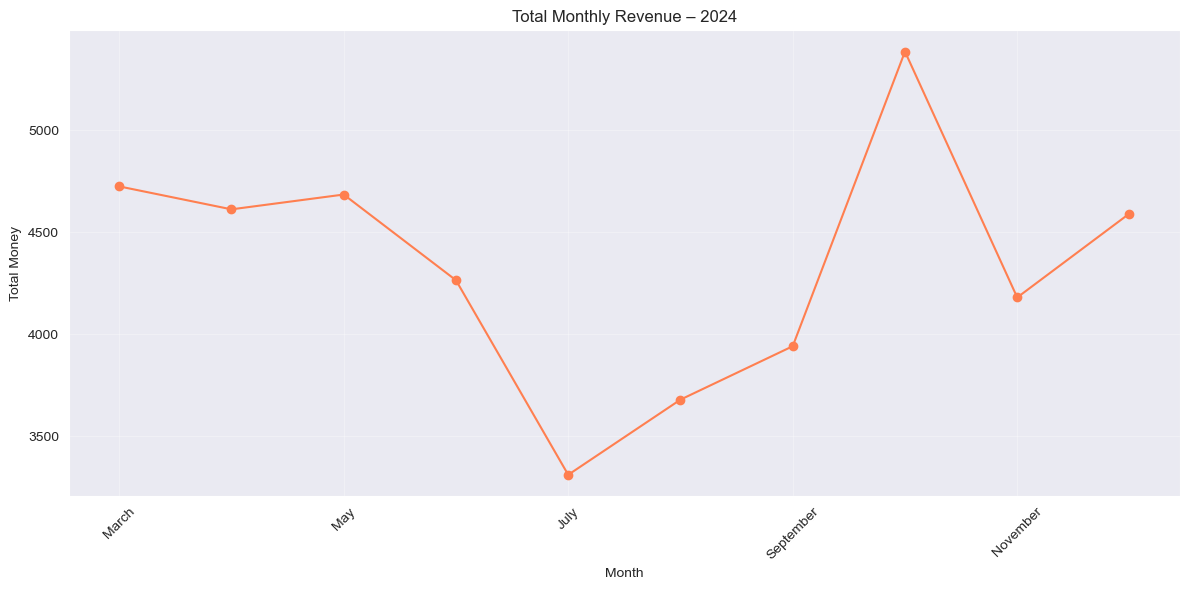

In [36]:
df_2024 = df[df['date'].dt.year == 2024]

monthly_total_2024 = df_2024.groupby(df_2024['date'].dt.month_name())['money'].sum()
monthly_total_2024 = monthly_total_2024.reindex(
    pd.date_range('2024-01-01', '2024-12-31', freq='ME').month_name()
)

plt.figure(figsize=(12, 6))
monthly_total_2024.plot(kind='line', marker='o', color='coral')
plt.title('Total Monthly Revenue – 2024')
plt.ylabel('Total Money')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
monthly_total_2024

January          NaN
February         NaN
March        4725.30
April        4612.76
May          4685.38
June         4264.88
July         3310.28
August       3679.06
September    3941.16
October      5386.84
November     4180.38
December     4592.30
Name: money, dtype: float64

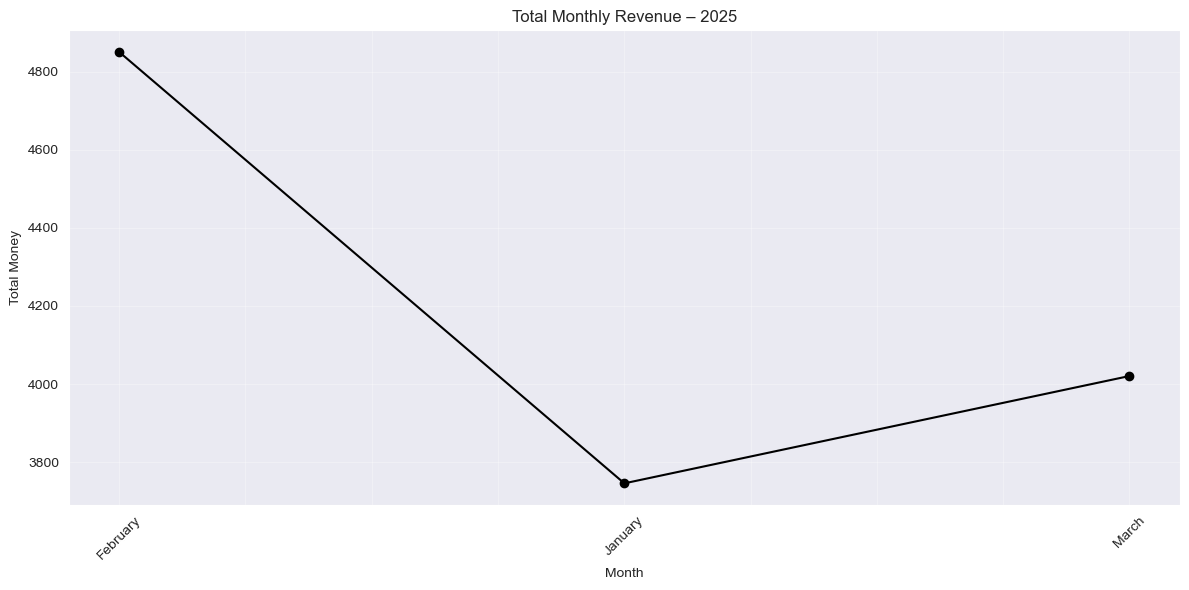

In [38]:
# Filter 2025
df_2025 = df[df['date'].dt.year == 2025]

monthly_total_2025 = df_2025.groupby(df_2025['date'].dt.month_name())['money'].sum()
# monthly_total_2025 = monthly_total_2025.reindex(
#     pd.date_range('2025-01-01', '2025-12-31', freq='ME').month_name()[:len(monthly_total_2025)]
# )

plt.figure(figsize=(12, 6))
monthly_total_2025.plot(kind='line', marker='o', color='black')
plt.title('Total Monthly Revenue – 2025')
plt.ylabel('Total Money')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
monthly_total_2025

date
February    4850.44
January     3745.84
March       4020.66
Name: money, dtype: float64

In [40]:
monthly_sales_by_sum.sort_values('money', ascending=False,ignore_index=True)

,month,money
0,March,8745.96
1,October,5386.84
2,February,4850.44
3,May,4685.38
4,April,4612.76
5,December,4592.30
6,June,4264.88
7,November,4180.38
8,September,3941.16
9,January,3745.84


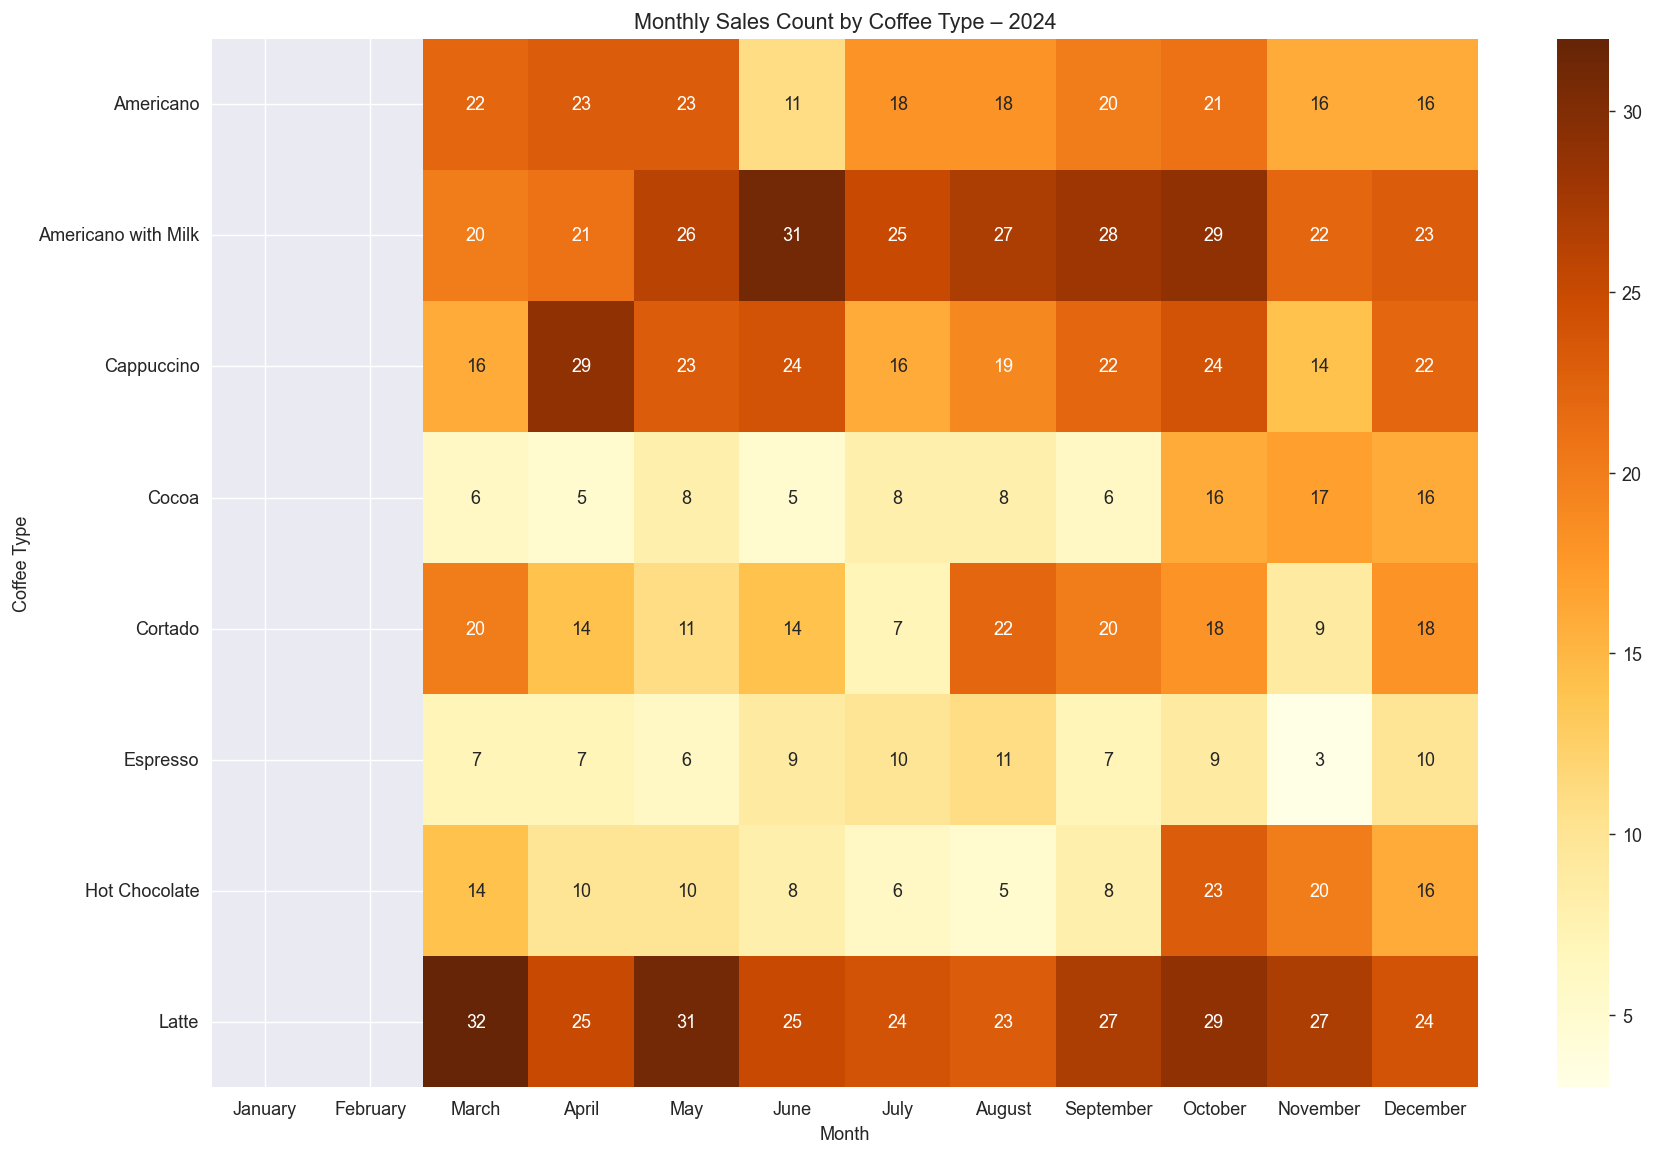

In [41]:
pivot_2024 = df_2024.pivot_table(
    index=df_2024['date'].dt.month_name(),
    columns='coffee_name',
    aggfunc='size',
    fill_value=0
).reindex(index=pd.date_range('2024-01-01', '2024-12-31', freq='ME').month_name())

plt.figure(figsize=(14, 9),dpi=130)
sns.heatmap(pivot_2024.T, cmap='YlOrBr', annot=True)
plt.title('Monthly Sales Count by Coffee Type – 2024')
plt.xlabel('Month')
plt.ylabel('Coffee Type')
plt.tight_layout()
plt.show()

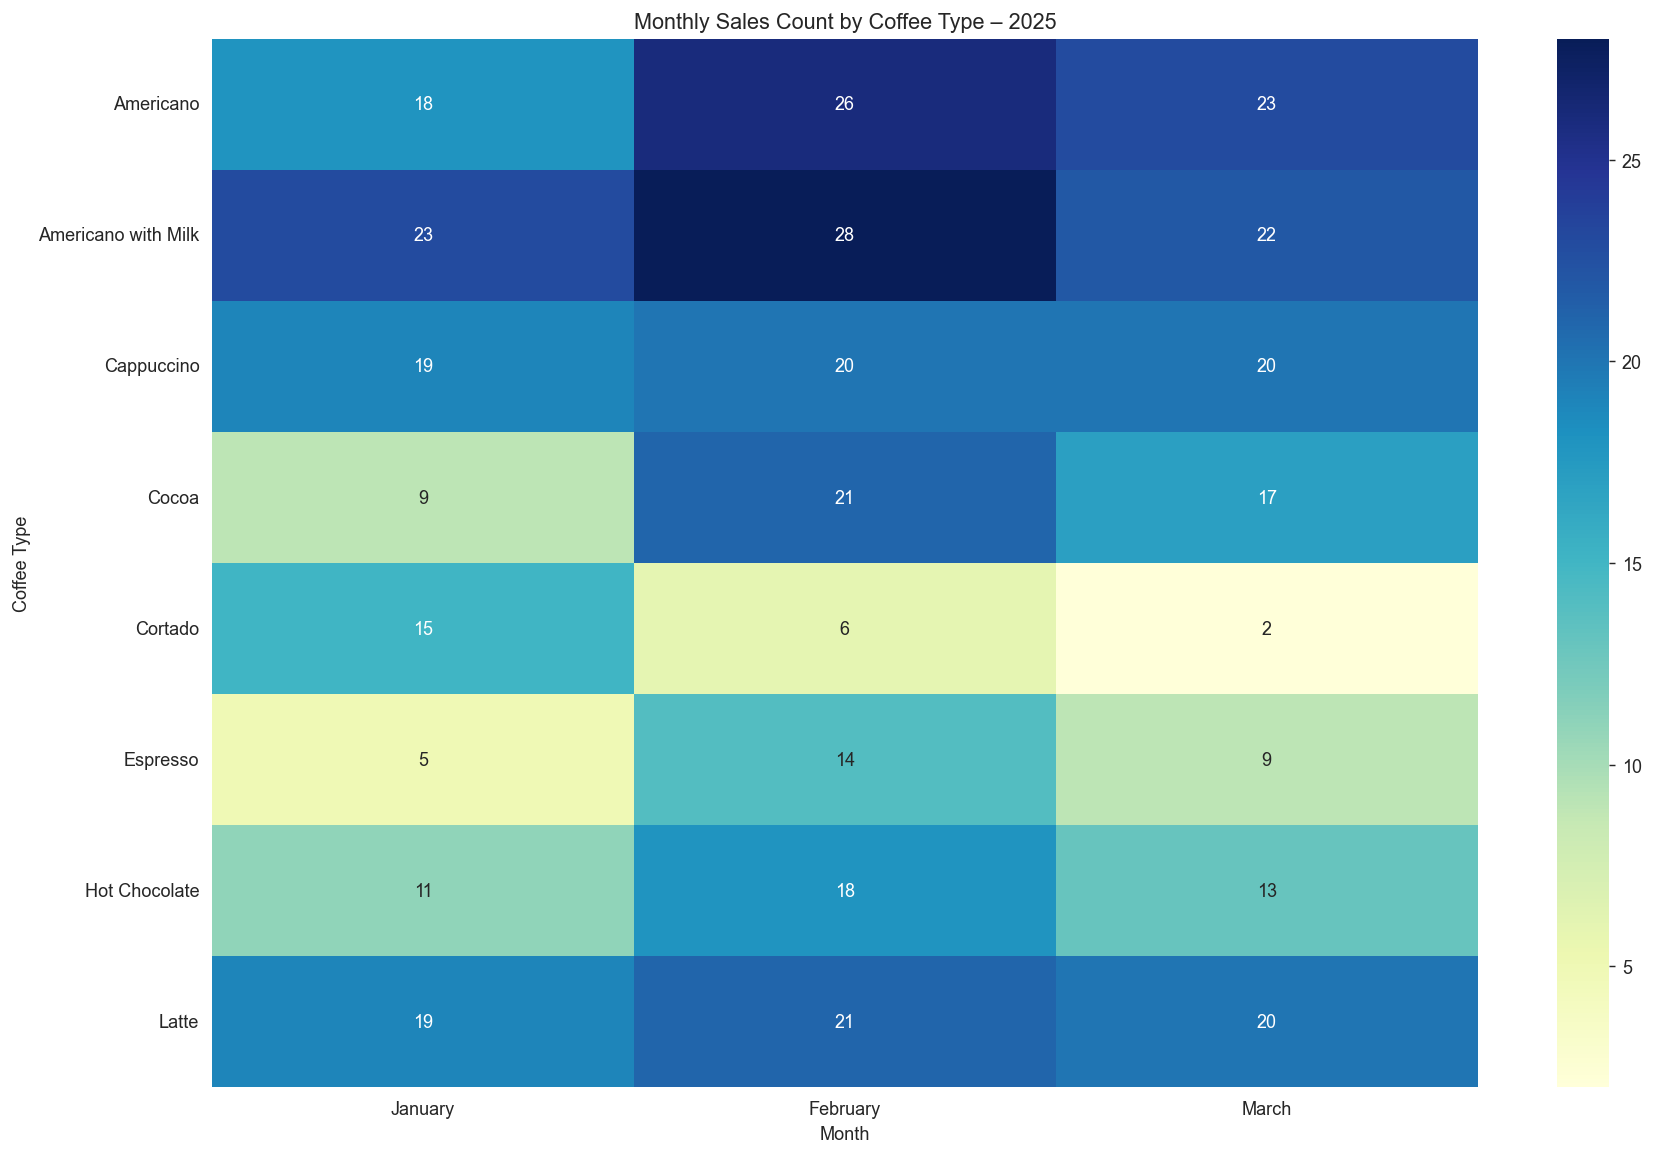

In [42]:
pivot_2025 = df_2025.pivot_table(
    index=df_2025['date'].dt.month_name(),
    columns='coffee_name',
    aggfunc='size',
    fill_value=0
).reindex(index=pd.date_range('2025-01-01', '2025-12-31', freq='ME').month_name()[:len(df_2025['date'].dt.month_name().unique())])

plt.figure(figsize=(14, 9), dpi=130)
sns.heatmap(pivot_2025.T, cmap='YlGnBu', annot=True, fmt='d')
plt.title('Monthly Sales Count by Coffee Type – 2025')
plt.xlabel('Month')
plt.ylabel('Coffee Type')
plt.tight_layout()
plt.show()

# MULTIVARIATE ANALYSIS #

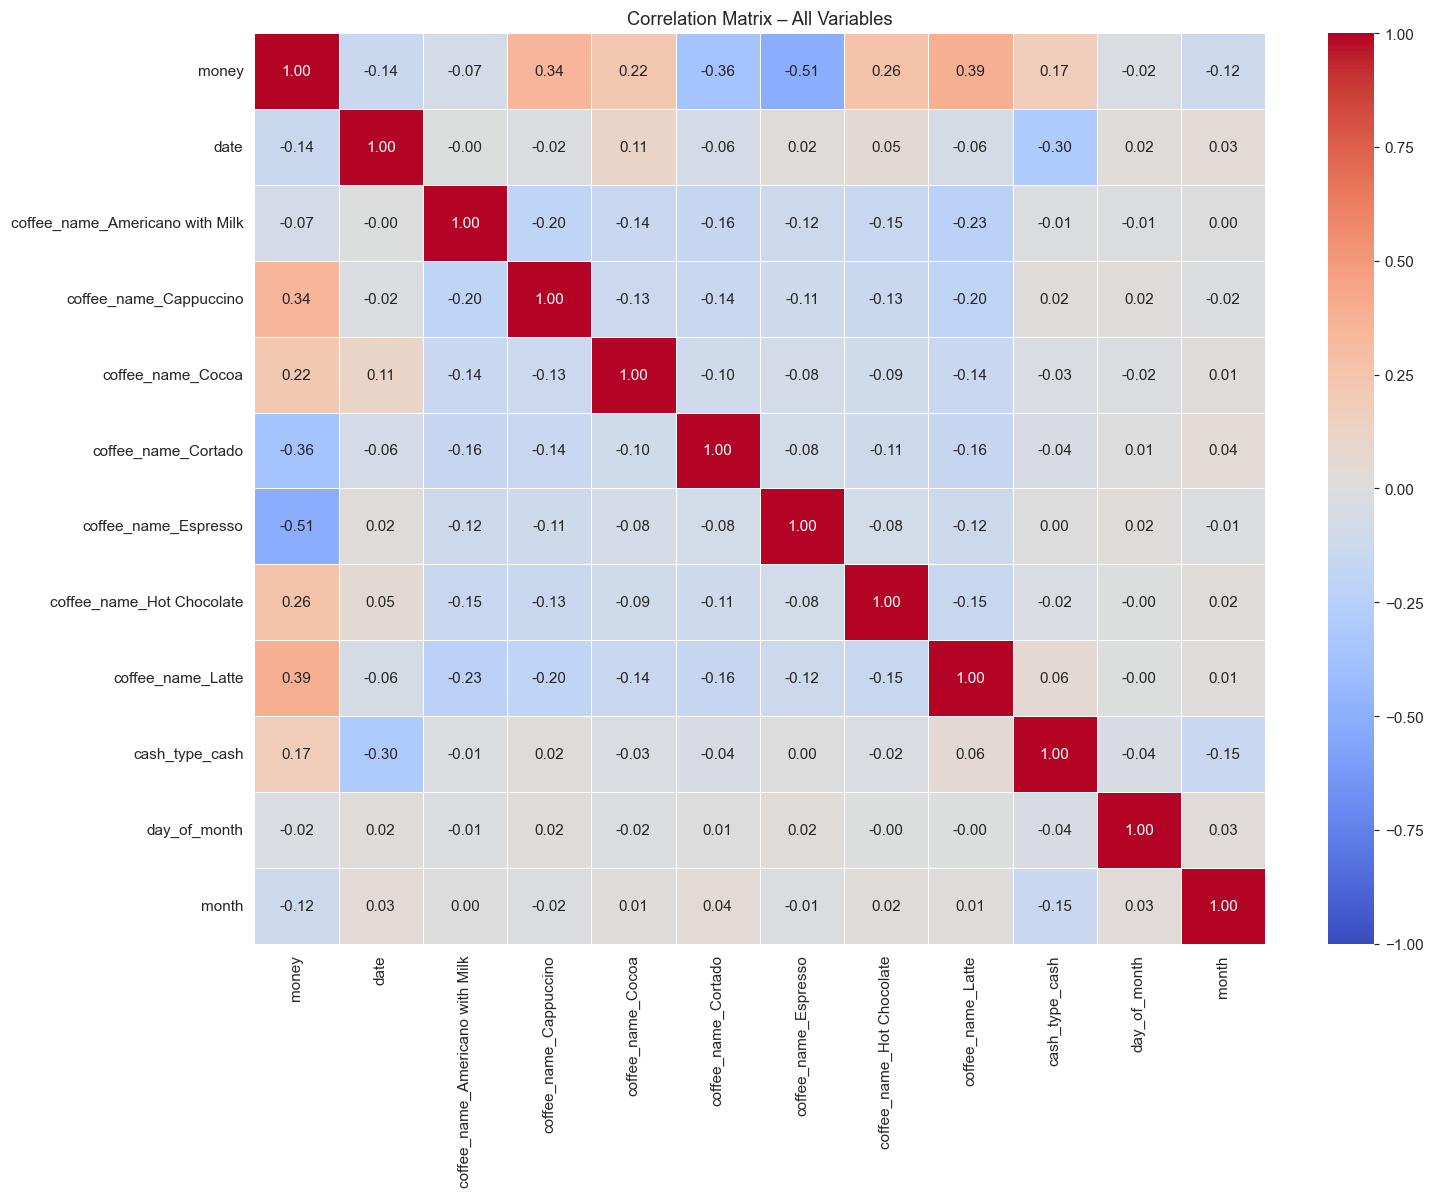

In [43]:
dummies = pd.get_dummies(df[['coffee_name', 'cash_type']], drop_first=True)
df_numeric = pd.concat([df[['money', 'date']], dummies], axis=1)
df_numeric['day_of_month'] = df_numeric['date'].dt.day
df_numeric['month'] = df_numeric['date'].dt.month
corr_matrix = df_numeric.corr()
plt.figure(figsize=(14, 11),dpi=110)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
vmin=-1, vmax=1, center=0, linewidths=0.5)
plt.title('Correlation Matrix – All Variables')
plt.tight_layout()
plt.show()

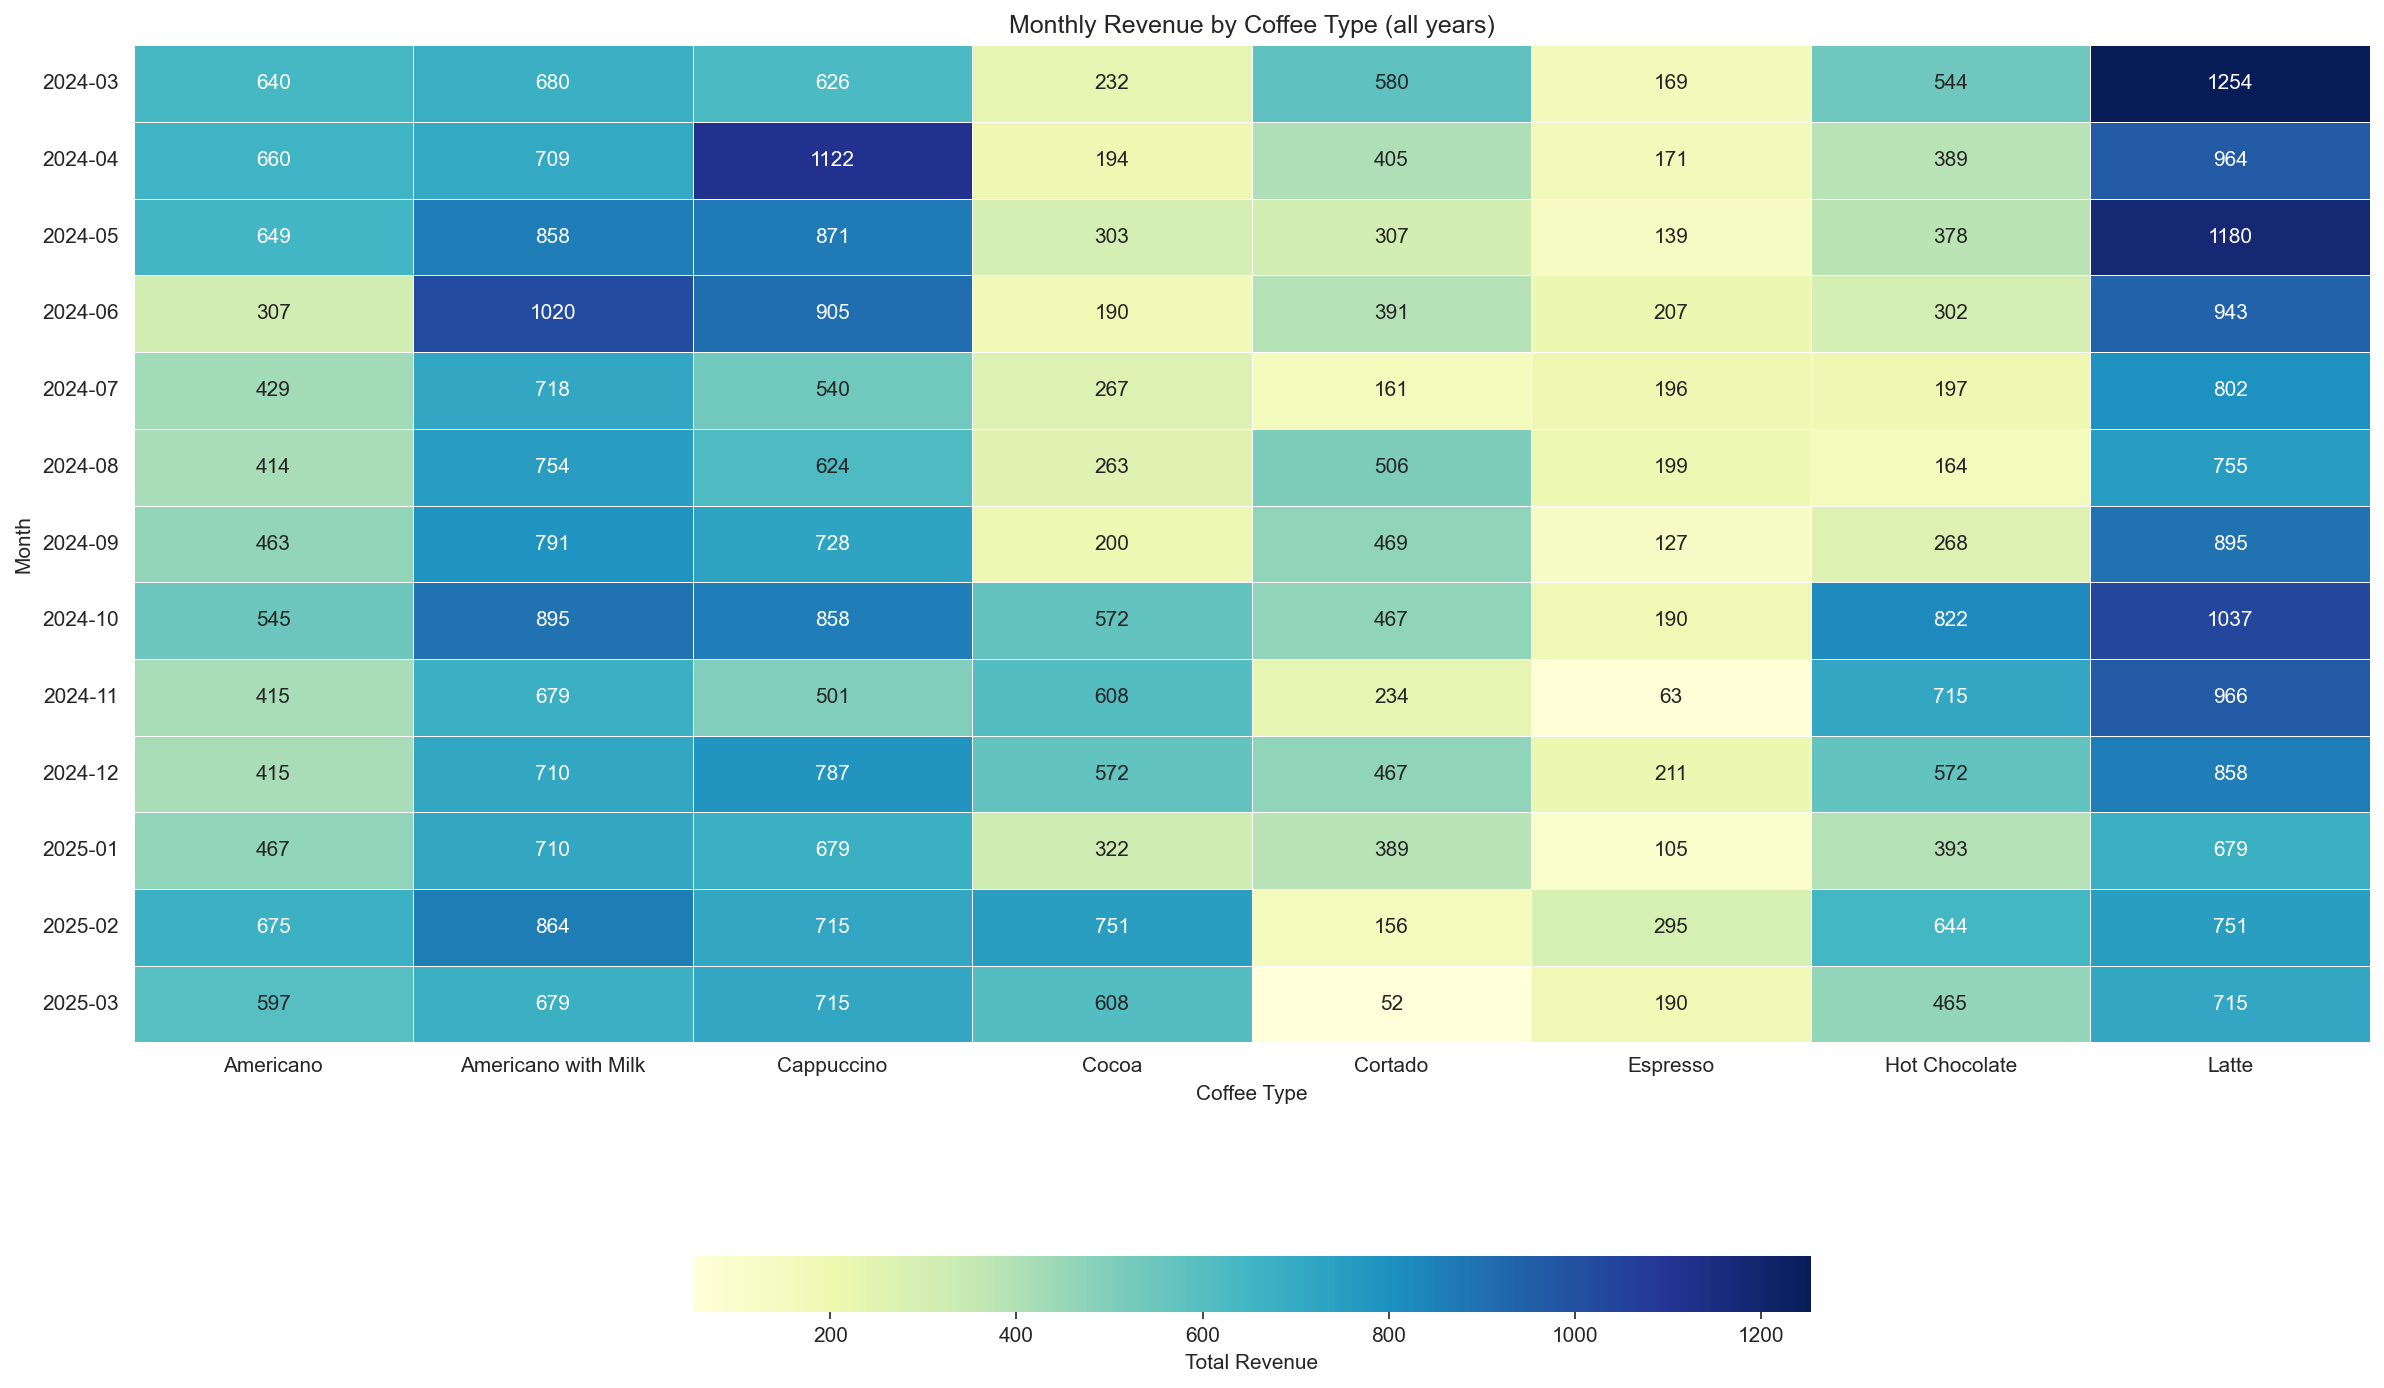

In [44]:
pivot_revenue = df.pivot_table(
index=df['date'].dt.to_period('M'),
columns='coffee_name',
values='money',
aggfunc='sum',
fill_value=0
)
plt.figure(figsize=(16, 10),dpi=150)
sns.heatmap(
pivot_revenue,
cmap='YlGnBu',
annot=True,
fmt='.0f',
cbar_kws={'label': 'Total Revenue','orientation': 'horizontal','shrink':0.5},
linewidths=0.3
)
plt.title('Monthly Revenue by Coffee Type (all years)')
plt.xlabel('Coffee Type')
plt.ylabel('Month')
plt.tight_layout()
plt.show()

In [45]:
pivot_revenue

coffee_name,Americano,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte
date,,,,,,,,
2024-03,640.20,679.60,625.70,232.20,580.20,169.00,544.40,1254.00
2024-04,660.04,708.72,1121.56,194.12,404.84,171.00,388.62,963.86
2024-05,648.64,858.04,871.40,303.04,307.12,139.10,378.48,1179.56
2024-06,307.12,1019.78,905.28,189.88,390.88,207.18,301.76,943.00
2024-07,429.06,717.60,539.82,267.46,161.14,195.90,196.92,802.38
2024-08,414.36,753.84,623.58,262.56,506.44,199.32,164.10,754.86
2024-09,463.34,790.58,727.92,199.86,469.22,126.84,268.44,894.96
2024-10,545.16,894.94,858.24,572.16,467.28,189.54,822.48,1037.04
2024-11,415.36,678.92,500.64,607.92,233.64,63.18,715.20,965.52


In [46]:
pivot_2024

coffee_name,Americano,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte
January,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
February,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
March,22.0,20.0,16.0,6.0,20.0,7.0,14.0,32.0
April,23.0,21.0,29.0,5.0,14.0,7.0,10.0,25.0
May,23.0,26.0,23.0,8.0,11.0,6.0,10.0,31.0
June,11.0,31.0,24.0,5.0,14.0,9.0,8.0,25.0
July,18.0,25.0,16.0,8.0,7.0,10.0,6.0,24.0
August,18.0,27.0,19.0,8.0,22.0,11.0,5.0,23.0
September,20.0,28.0,22.0,6.0,20.0,7.0,8.0,27.0
October,21.0,29.0,24.0,16.0,18.0,9.0,23.0,29.0


In [47]:
df

,date,cash_type,money,coffee_name,month,year
0,2024-03-01,card,38.70,Latte,March,2024
1,2024-03-01,card,38.70,Hot Chocolate,March,2024
2,2024-03-01,card,28.90,Americano,March,2024
3,2024-03-01,card,33.80,Americano with Milk,March,2024
4,2024-03-01,card,38.70,Cocoa,March,2024
...,...,...,...,...,...,...
1757,2025-03-22,card,35.76,Latte,March,2025
1758,2025-03-23,card,35.76,Latte,March,2025
1759,2025-03-23,card,35.76,Cappuccino,March,2025
1760,2025-03-23,card,35.76,Cocoa,March,2025


# Statistical Tests

# Anova Test #

***the anova test is used to check if the mean differs amongs different groups, so we are trying to see if the average money differs among each group***

In [48]:
from scipy import stats

In [49]:
test_stuff =[group['money'].values for name, group in df.groupby('coffee_name')]
anov_stat, p_value = stats.f_oneway(*test_stuff)
print(f'Anova Test: F:{anov_stat:.3f} and P:{p_value:.6f}')

Anova Test: F:1557.781 and P:0.000000


**so we see that the p_value is less than 0.05 which shows that prices are significantly different from each coffee type**

# Chi-Square #

***chi-square test is used for categorical features.***

In [50]:
chi_test, p, dof, expected = stats.chi2_contingency(tab)
print(f'Chi-Square Test: Chi:{chi_test:.3f}, P_value:{p:.3f}, Degree_Of_Freedom: DOF:{dof}')
if p<0.05:
    print(f'{p:.2f} is lower than 0.05')
else:
    print(f'{p:.2f} is greater than 0.05')

Chi-Square Test: Chi:10.393, P_value:0.167, Degree_Of_Freedom: DOF:7
0.17 is greater than 0.05


# T-Test

In [51]:
card = df[df['cash_type']=='card']['money']
cash = df[df['cash_type']=='cash']['money']
t_test, p_valv = stats.ttest_ind(a=card,b=cash,equal_var=False) 
# since we set equal_var to False, this is now a welch's t-test
print(f"Welch's T-Test: T:{t_test:.3f}, P_Value:{p_valv:.2f}")
if p_valv<0.05:
    print(f'P_Value:{p_valv:.2f} is less than 0.05')
else:
    print(f'P_Value:{p_valv:.2f} is greater than 0.05')

Welch's T-Test: T:-7.874, P_Value:0.00
P_Value:0.00 is less than 0.05


In [52]:
df.groupby('coffee_name')['money'].sum()

coffee_name
Americano               6677.96
Americano with Milk    10064.58
Cappuccino              9670.70
Cocoa                   5082.08
Cortado                 4585.12
Espresso                2261.34
Hot Chocolate           5854.48
Latte                  11799.02
Name: money, dtype: float64

In [53]:
df['money'].sum()

np.float64(55995.28)

In [54]:
Q1 = df['money'].quantile(0.25)
Q3 = df['money'].quantile(0.75)

In [55]:
iqr = Q3 - Q1

In [56]:
upper_limit = Q3 + (1.5 * iqr)
lower_limit = Q1 - (1.5 * iqr)

In [57]:
df[(df['money'] < lower_limit) | (df['money'] > upper_limit)]

,date,cash_type,money,coffee_name,month,year
